# Whisper or scream?

=
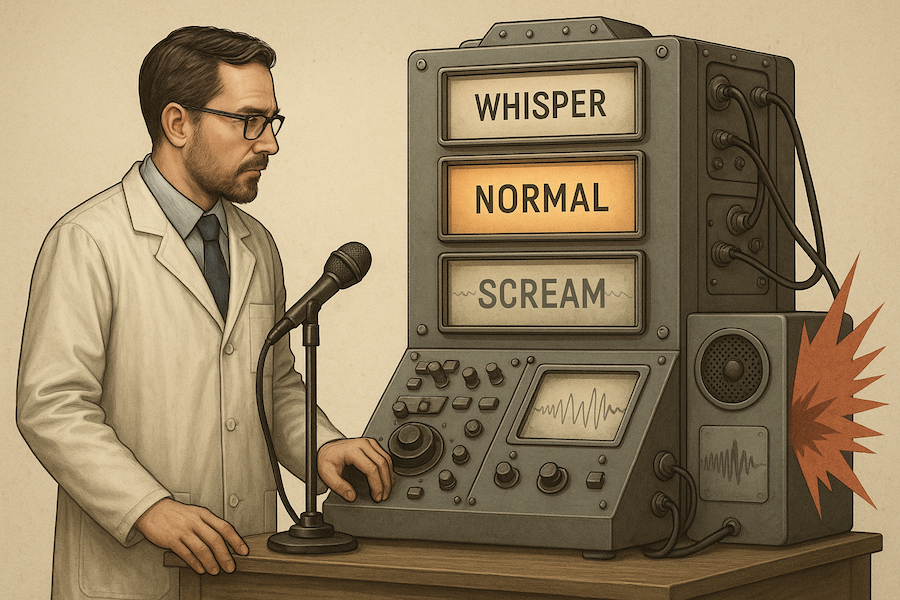


*Image generated by the ChatGPT image generation tool.*

## Introduction

At the Institute of Advanced Experimental Acoustics there is unusual excitement. After many years,
the prototype of the **Speech Loudness Evaluation Machine** has been launched — an advanced device
that can assess the loudness of speech.

Or at least it **should** be able to.

Unfortunately, the machine lacks one key functionality — a good model that can recognize whether
a word was spoken **normally, whispered, or screamed**. Without it, the device lights up its
indicators in a completely random way, which, according to the research team, slightly reduces
users’ trust.

Your task is to prepare a model that will allow this machine to operate as described in the
documentation.

## Task

Implement a model that classifies audio recordings into three classes:

- `0` (`normal`) — a word spoken in a normal tone,

- `1` (`scream`) — a word spoken by screaming,

- `2` (`whisper`) — a word spoken in a whisper.

## Data

In this task, two datasets are available to you:

- **training** — $2\,400$ samples,

- **validation** — $200$ samples.

The hidden test set, on which your solution will be evaluated, contains $400$ samples.

All recordings have a sampling frequency of 16 kHz and contain single words in Polish, whose
meaning does not affect the task.

## Evaluation Criterion

Your solution will be evaluated based on **balanced classification accuracy** (balanced
accuracy):

$$ \text{BalancedAccuracy} = \frac{1}{3} \sum_{k} \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k} $$

where $k \in \{0, 1, 2\}$, $\text{TP}$ is the number of samples for which the model correctly detected
a given class, and $\text{FN}$ is the number of samples for which the model failed to detect a given
class.

For this task you can score between 0 and 100 points. The result will be scaled linearly depending
on the value of Balanced Accuracy:

- **Balanced Accuracy $\leq$ 0.6**: 0 points.

- **Balanced Accuracy $\geq$ 0.99**: 100 points.

- **Values between 0.6 and 0.99**: scaled linearly.

Scoring formula:

$$ \text{Points} = \begin{cases} 
0 & \text{for } \text{Balanced Accuracy} \leq 0.6 \\
100 \times \frac{\text{Balanced Accuracy} - 0.6}{0.99 - 0.6} & \text{for } 0.6 < \text{Balanced Accuracy} < 0.99 \\
100 & \text{for } \text{Balanced Accuracy} \geq 0.99
\end{cases} $$

## Constraints

- In this task you may use a GPU.

- Evaluation of your final solution on the Competition Platform must not take longer than 5 minutes
with a GPU.

- List of allowed libraries: `sklearn`, `tqdm`, `seaborn`, `matplotlib`, `numpy`, `torch`,
`torchaudio`, `librosa`.

- The model must inherit from the `nn.Module` class.

## Notes and hints

- The recordings are normalized to the same loudness level.

- You may validate your solution on the training and validation sets, but the score for the task
will be awarded only based on the result on the test set.

## Submission files

This notebook completed with your solution (see the `YourClassifier` class).

## Evaluation

Remember that during checking the `FINAL_EVALUATION_MODE` flag will be set to True.

For this task you can score between 0 and 100 points. The number of points you obtain will be
calculated on the (secret) test set on the Competition Platform based on the formula mentioned
above, rounded to an integer. If your solution does not meet the above criteria or does not execute
correctly, you will receive 0 points for the task.

## Starter Code

In this section we initialize the environment by importing the required libraries and functions.
The prepared code will help you efficiently work with the data and build an appropriate solution.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

FINAL_EVALUATION_MODE = False  # Podczas sprawdzania ustawimy tę flagę na True.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

import os
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio
import librosa
from typing import Callable
from torch.utils.data import Dataset
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from IPython.display import Audio

if not FINAL_EVALUATION_MODE:
    import gdown

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert torch.cuda.is_available(), "CUDA niedostępna!"

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

seed = 12345

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do przygotowania danych.


class WhisperScreamDataset(Dataset):
    """
    Zbiór danych wczytywany z pliku npz.

    Przyjmuje:
        path (str): Ścieżka do pliku npz zawierającego dane.
    """

    def __init__(self, path: str) -> None:
        data = np.load(path, allow_pickle=True)

        self.signals = data["signals"]
        self.labels = data.get("labels", None)
        self.sr = int(data["sr"])

        if self.labels is None:
            self.labels = [-1] * len(self.signals)

    def __len__(self) -> int:
        """Zwraca liczbę próbek w zbiorze danych."""
        return len(self.signals)

    def __getitem__(self, index: int) -> dict:
        sig = self.signals[index]
        label = self.labels[index]
        sig = torch.tensor(sig, dtype=torch.float32)
        return {"audio": sig, "label": label}


def setup_data(root: str = "data/") -> tuple:
    """
    Przygotowuje zbiory danych do trenowania i walidacji, pobierając je jeśli to konieczne.

    Przyjmuje:
        root (str, opcjonalnie): Katalog bazowy dla plików z danymi.

    Zwraca:
        tuple: Zbiory danych (train_ds, val_ds).
    """
    train_file = root + "train.npz"
    val_file = root + "val.npz"

    if not os.path.exists(root):
        os.makedirs(root)

    if not os.path.exists(train_file):
        url = "https://drive.google.com/uc?id=1WpPqcKTh_jzCsBm7k32IRtqlsxgpV8u4"
        gdown.download(url, train_file, quiet=True)

    if not os.path.exists(val_file):
        url = "https://drive.google.com/uc?id=1PwVhwFAGX3cS9gA7SYbJORjpQroPVQEN"
        gdown.download(url, val_file, quiet=True)

    train_ds = WhisperScreamDataset(train_file)
    val_ds = WhisperScreamDataset(val_file)

    return train_ds, val_ds

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do wyznaczenia metryk oceniających jakość modelu.


def predict(model_predict: Callable, dataset: Dataset) -> list:
    """
    Funkcja przewidująca wszystkie etykiety dla zbioru danych z wykorzystaniem funkcji do predykcji.

    Przyjmuje:
        model_predict (Callable): Funkcja do predykcji zwracająca listę etykiet.
        dataset (Dataset): Zbiór danych.

    Zwraca:
        list: Lista zawierająca wszystkie przewidziane etykiety, dla każdej próbki w zbiorze danych.
    """
    predicted = []

    for sample in dataset:
        x = sample["audio"].to(DEVICE)
        pred = model_predict(x)
        predicted.append(pred)

    return predicted


def calculate_balanced_accuracy(predicted: list, dataset: Dataset) -> float:
    """
    Funkcja obliczająca balanced accuracy dla przewidzianych etykiet dla całego zbioru danych.

    Przyjmuje:
        predicted (list): Lista zawierająca przewidziane etykiety dla każdej próbki w zbiorze
            danych.
        dataset (Dataset): Zbiór danych zawierający oczekiwane etykiety.
    """
    expected = [sample["label"] for sample in dataset]
    return balanced_accuracy_score(y_true=expected, y_pred=predicted)


def plot_confusion_matrix(predicted: list, dataset: Dataset) -> None:
    """
    Funkcja wyświetlająca macierz pomyłek dla klasyfikacji nagrań.

    Przyjmuje:
        predicted (list): Lista przewidzianych etykiet.
        dataset (Dataset): Zbiór danych.
    """
    expected = [sample["label"] for sample in dataset]
    conf_matrix = confusion_matrix(expected, predicted)

    labels = ["normal", "scream", "whisper"]
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
    )

    plt.xlabel("Przewidziane etykiety", labelpad=15)
    plt.ylabel("Oczekiwane etykiety", labelpad=15)
    plt.xticks(rotation=45)

    plt.title("Macierz pomyłek dla klasyfikacji nagrań")
    plt.show()


def evaluate_algorithm(your_model_predict: Callable, dataset: Dataset):
    """
    Funkcja służąca do ewaluacji rozwiązania.

    Przyjmuje:
        your_model_predict (Callable): Funkcja do predykcji zwracająca listę etykiet.
        dataset (Dataset): Zbiór danych, na którym będzie ewaluowane rozwiązanie.
    """
    your_out = predict(your_model_predict, dataset)

    your_balanced_accuracy = calculate_balanced_accuracy(your_out, dataset)
    score = (np.clip(your_balanced_accuracy, 0.6, 0.99) - 0.6) / (0.99 - 0.6) * 100
    score = int(round(score))

    print(f"Balanced accuracy na zbiorze walidacyjnym: {your_balanced_accuracy:.4f}")
    print(f"Estymowana liczba punktów za zadanie: {score}")

    plot_confusion_matrix(your_out, dataset)

## Data loading

Using the code below, the data will be loaded and properly prepared.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

train_ds, val_ds = setup_data(root="data/")

if not FINAL_EVALUATION_MODE:
    print(f"Number of recordings in the training set: {len(train_ds)}")
    print(f"Number of recordings in the validation set: {len(val_ds)}")
    print(f"Each sample contains: {list(train_ds[0].keys())}")

To listen to an example sample, you can use the code below.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    sample = next(iter(train_ds))
    waveform = sample["audio"].cpu().numpy()

    if waveform.ndim == 2:
        waveform = waveform.T

    Audio(waveform, rate=16000)

## Example solution

Below we present a simplified solution that demonstrates the basic functionality
of the notebook. It can serve as a starting point for developing your solution.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################


class DummyClassifier(nn.Module):
    def __init__(self, in_features: int):
        super(DummyClassifier, self).__init__()
        self.max_len = in_features
        self.linear = nn.Linear(in_features=in_features, out_features=3)

    def forward(self, audio: torch.Tensor) -> torch.Tensor:
        """
        Funkcja klasyfikująca nagranie x do jednej z 3 klas: 0 - normal, 1 - scream, 2 - whisper.

        Przyjmuje:
            x (torch.Tensor): Nagranie do klasyfikacji.

        Zwraca:
            torch.Tensor: Predykcje modelu.
        """
        x = self.linear(audio)
        return nn.functional.softmax(x, dim=0)

    @torch.no_grad()
    def predict(self, audio: torch.Tensor) -> list[int]:
        """
        Funkcja przewidująca etykietę dla nagrania `x`.

        Przyjmuje:
            x (torch.Tensor): Nagranie do klasyfikacji.

        Zwraca:
            list[int]: Lista przewidzianych etykiet.
        """
        if audio.size(-1) < self.max_len:
            audio = nn.functional.pad(audio, (0, self.max_len - audio.size(-1)))
        elif audio.size(-1) > self.max_len:
            audio = audio[: self.max_len]
        if audio.dim() < 2:
            audio = audio.view(1, -1)
        self.eval()
        logits = self.forward(audio)
        preds_idx = torch.argmax(logits, dim=1)
        return preds_idx.tolist()

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################


class DataPreprocessor:
    def __init__(self, max_len: int) -> None:
        self.max_len = max_len

    def __call__(self, batch: list) -> dict:
        audios, labels = [], []

        for sample in batch:
            audio = sample["audio"]

            if audio.size(-1) < self.max_len:
                audio = nn.functional.pad(audio, (0, self.max_len - audio.size(-1)))
            elif audio.size(-1) > self.max_len:
                audio = audio[: self.max_len]

            label = sample["label"]

            audios.append(audio)
            labels.append(label)

        return {"audios": torch.stack(audios, dim=0), "labels": torch.tensor(labels)}

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################


def train_eval_dummy_classifier(train_ds: Dataset, val_ds: Dataset):
    max_len = 0

    for sample in train_ds:
        audio = sample["audio"]
        if audio.size(-1) > max_len:
            max_len = audio.size(-1)

    print(
        f"Najdłuższe nagranie w zbiorze treningowym ma długość: {max_len}"
    )  # Powinno wyjść 80000.

    preprocess = DataPreprocessor(max_len=max_len)

    model = DummyClassifier(in_features=max_len).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=preprocess)

    epochs = 1

    pbar = tqdm(range(epochs), desc="Training", total=epochs)
    for _ in pbar:
        epoch_losses = []

        for batch in train_dl:
            x = batch["audios"].to(DEVICE)
            y = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.detach().cpu().item())

        avg_loss = np.mean(epoch_losses)
        pbar.set_postfix({"train loss": avg_loss})

    model.eval()

    evaluate_algorithm(model.predict, val_ds)

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    train_eval_dummy_classifier(train_ds, val_ds)

## Your solution

In this section you should place your solution. Introduce changes only here!

Your model must be stored in the variable `your_model`. Moreover, it must have a `.predict()`
function that returns a list of predicted labels. It is the `your_model.predict` function that
constitutes the final solution and will be evaluated.

In [ ]:
# Here you can implement your classifier, which will return a list of predicted labels.


class YourClassifier(nn.Module):
    def __init__(self):
        # Here you can initialize your model
        super(YourClassifier, self).__init__()
        pass

    def forward(self, audio: torch.Tensor) -> torch.Tensor:
        # Here implement the logic of your classifier.
        pass

    def predict(self, audio: torch.Tensor) -> list:
        # Here implement prediction.
        # Example model always returning the same label:
        return [0]

In [ ]:
# Here train your model using train_ds and val_ds
# ...

your_model = YourClassifier()

## Evaluation

The code below will be used to evaluate the solution. After submitting the solution to us,
the function `evaluate_algorithm(your_model.predict, test_ds)` will be executed, i.e. almost
identical code to the one below will be run on the test set available only to the task evaluators.

Before submitting, make sure that the entire notebook runs from start to finish without errors
and without user intervention after executing the `Run All` command.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    evaluate_algorithm(your_model.predict, val_ds)